In [1]:
# code 1

# Import necessary libraries
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv("healthcare_dataset_cp.csv")

# Display the first few rows
data.head()

# Check for missing values
data.isnull().sum()

# Summary statistics for each feature
data.describe()


,Temperature,Heart Rate,Pulse,BPSYS,BPDIA,Respiratory Rate,Oxygen Saturation,PH
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,37.024525,75.149521,74.561759,119.510057,79.833322,16.068808,97.981219,7.398365
std,0.495112,9.834146,10.157187,15.032909,10.332268,3.056730,1.920574,0.050312
min,35.379366,44.804878,44.923677,72.349443,47.789836,4.490033,90.155199,7.231221
25%,36.687984,68.645887,67.643299,109.803479,72.627938,14.027884,96.680445,7.365985
50%,37.025201,74.979585,74.789237,119.627048,79.602520,16.036577,98.009714,7.397418
75%,37.340037,81.706955,81.123837,129.672653,87.041630,18.088722,99.273265,7.431404
max,38.926366,114.262377,107.430930,166.693653,115.290552,26.132149,103.828218,7.568888


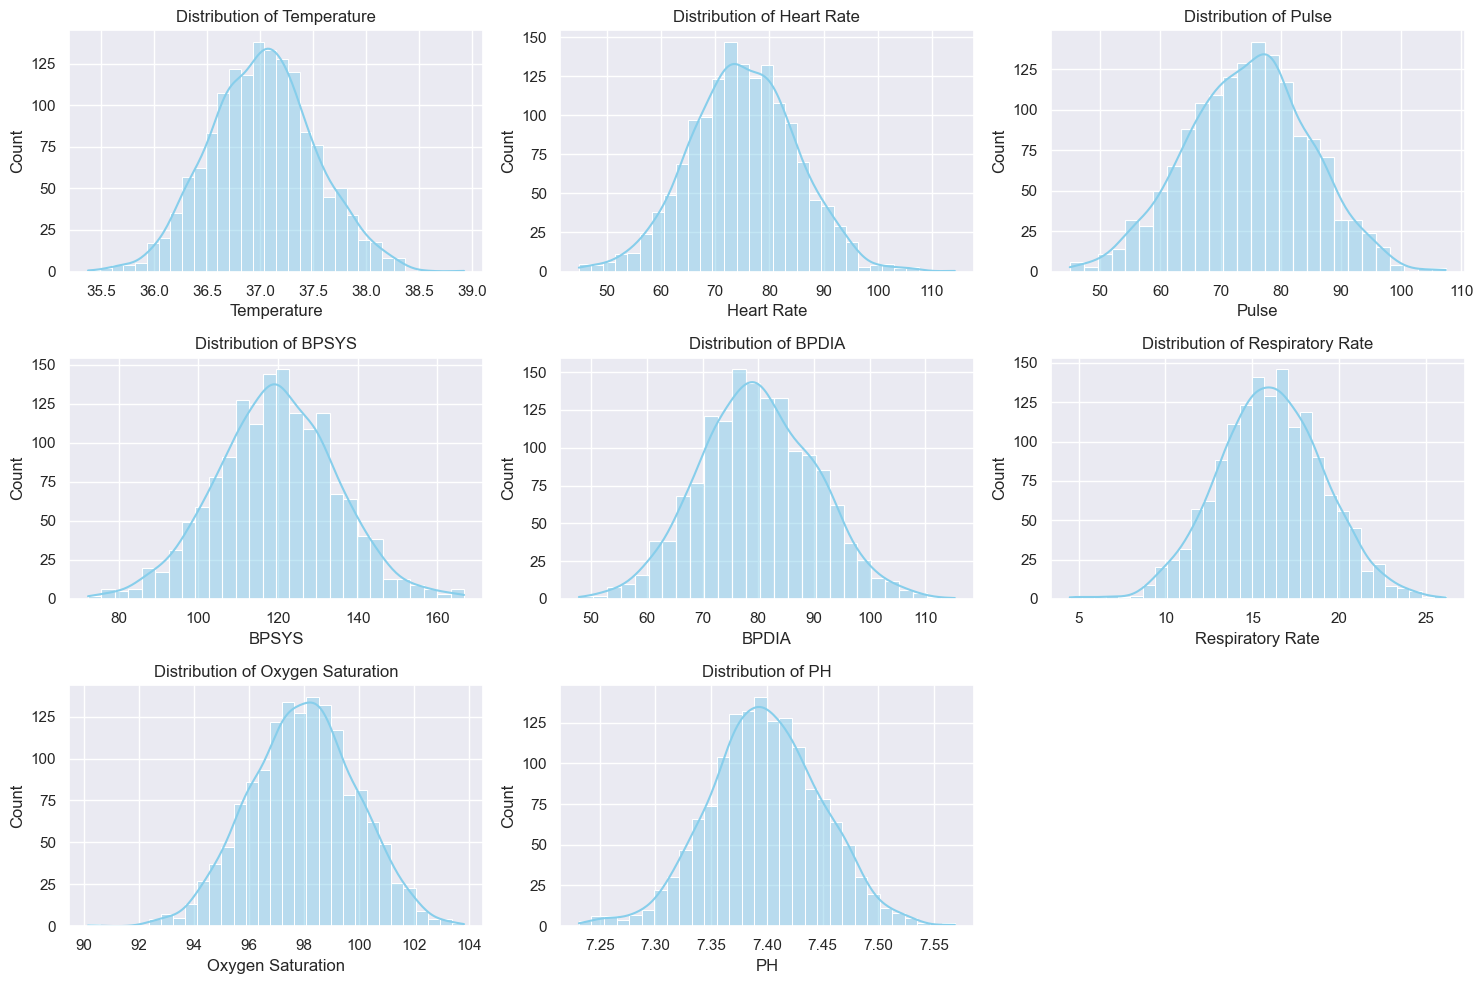

In [2]:
# code 2

# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
from plotly import express as px

# Dark theme for better contrast
sns.set_theme(style="darkgrid")

# Visualize the distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(data.columns[:-1], 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[column], kde=True, color='skyblue')
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()



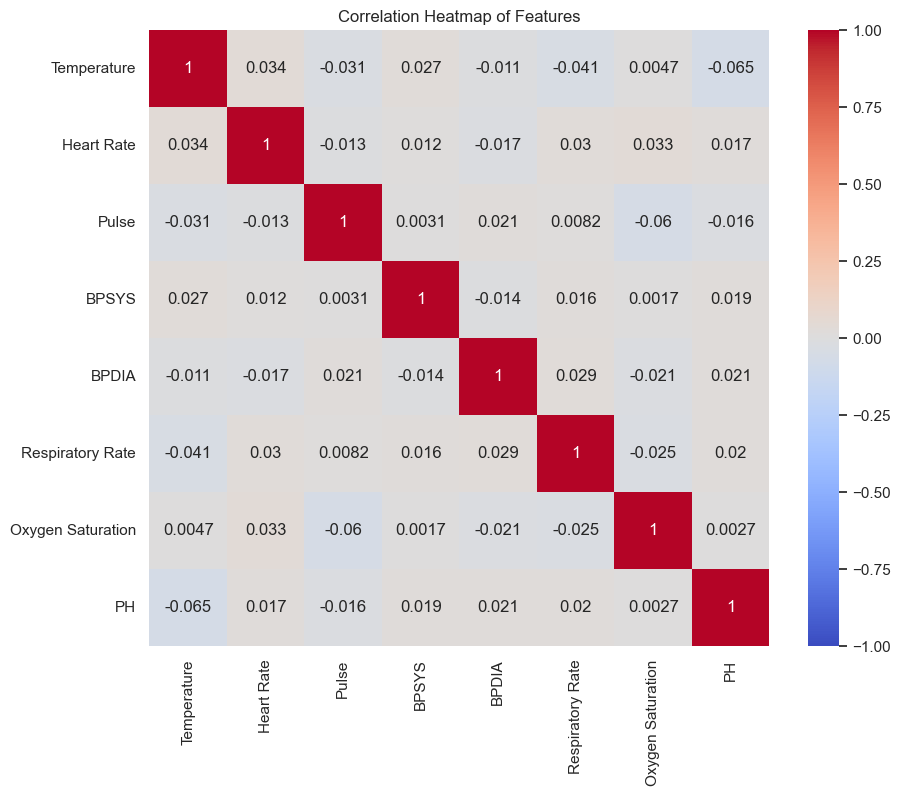

In [3]:
# code 3

# Correlation heatmap, excluding the 'Type' column
plt.figure(figsize=(10, 8))
sns.heatmap(data.drop(columns=['Type']).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Features')
plt.show()



In [4]:
# code 4

# Import libraries for model training
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Split the data into features (X) and target (y)
X = data.drop(columns=['Type'])
y = data['Type']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save the model for later use in the Dash app
joblib.dump(rf_model, "random_forest_model.pkl")

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Print model performance
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))



Classification Report:
                precision    recall  f1-score   support

    High risk       1.00      0.98      0.99       229
Moderate risk       0.96      0.99      0.98       131
      No risk       1.00      0.99      0.99        90

     accuracy                           0.99       450
    macro avg       0.99      0.99      0.99       450
 weighted avg       0.99      0.99      0.99       450

Confusion Matrix:
 [[225   4   0]
 [  1 130   0]
 [  0   1  89]]
Accuracy Score: 0.9866666666666667


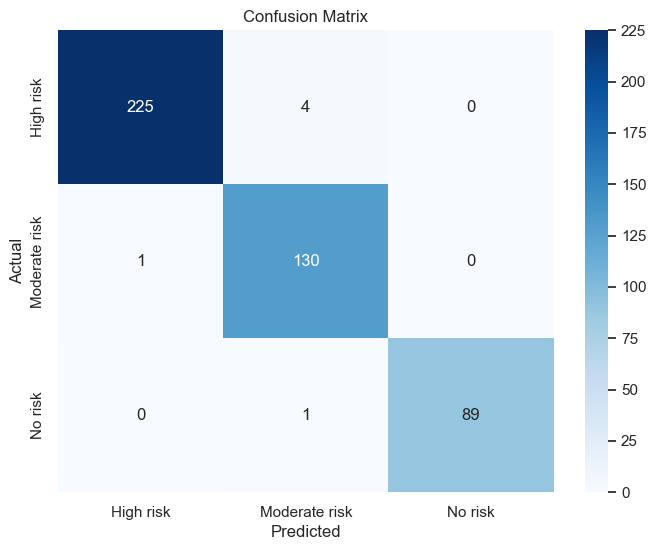

In [5]:
# code 5

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_11488\1131950022.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette="viridis")


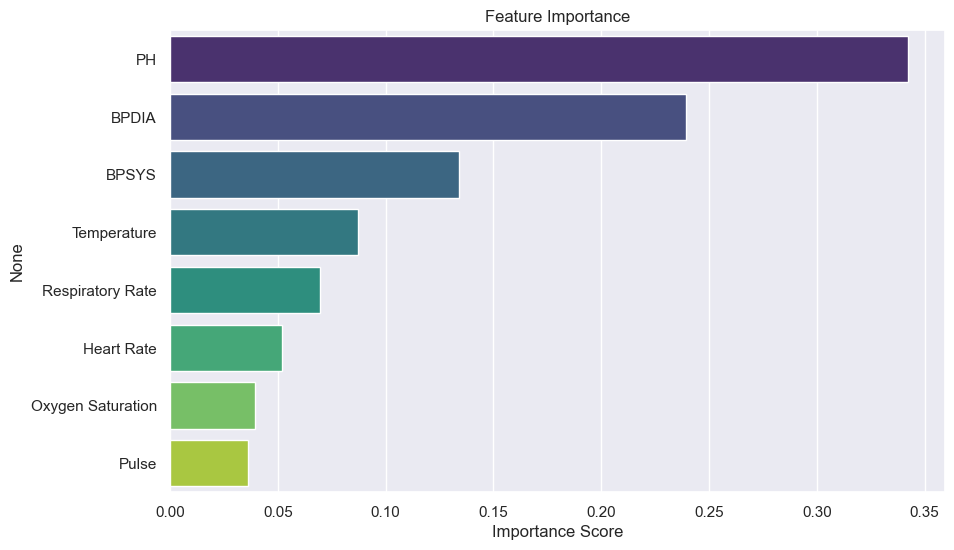

In [6]:
# code 6

# Feature importance plot
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()


In [7]:
# code 7

import pandas as pd
import numpy as np
import joblib
from dash import Dash, html, dcc, Input, Output, State
import dash_bootstrap_components as dbc
import plotly.express as px

# Load dataset
file_path = "healthcare_dataset_cp.csv"  # Ensure this file is in the same directory
data = pd.read_csv(file_path)

# Extract feature names
feature_names = ['Temperature', 'Heart Rate', 'Pulse', 'BPSYS', 'BPDIA', 'Respiratory Rate', 'Oxygen Saturation', 'PH']

# Load pre-trained model
model_path = "random_forest_model.pkl"
try:
    rf_model = joblib.load(model_path)
except FileNotFoundError:
    raise FileNotFoundError("Model file not found. Train the model and save it as 'random_forest_model.pkl'.")

# Create Dash app
app = Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])

# App layout
app.layout = html.Div([
    html.H1("Healthcare Risk Prediction System", style={'text-align': 'center', 'color': 'white'}),

    html.Div([
        html.Label("Enter Values for Each Feature:", style={'color': 'white'}),

        # Input fields for user entry
        *[
            dcc.Input(id=f'input-{col}', type='number', placeholder=col, style={'margin': '5px', 'width': '200px'})
            for col in feature_names
        ],

        # Predict button
        html.Button("Predict Risk Level", id="predict-button", n_clicks=0, style={'margin-top': '10px'}),

        # Prediction output display
        html.Div(id="prediction-output", style={'text-align': 'center', 'color': 'white', 'margin-top': '20px'})
    ], style={'display': 'flex', 'flex-direction': 'column', 'align-items': 'center'}),

    # Dropdown and graph for visualization
    html.Div([
        dcc.Dropdown(id="feature-dropdown",
                     options=[{"label": col, "value": col} for col in feature_names],
                     placeholder="Select a feature to visualize",
                     style={'color': 'black', 'margin-top': '20px'}),

        dcc.Graph(id="feature-plot")
    ])
])

# Prediction callback
@app.callback(
    Output("prediction-output", "children"),
    Input("predict-button", "n_clicks"),
    [State(f"input-{col}", "value") for col in feature_names]
)
def predict_risk(n_clicks, *values):
    if n_clicks > 0:
        # Handle missing inputs and reshape for prediction
        input_data = [float(v) if v is not None else 0 for v in values]
        input_data = np.array(input_data).reshape(1, -1)

        # Perform prediction using the trained model
        prediction = rf_model.predict(input_data)[0]
        return f"Predicted Risk Level: {prediction}"
    return "Enter values and click 'Predict Risk Level' to see the result."

# Visualization callback
@app.callback(
    Output("feature-plot", "figure"),
    Input("feature-dropdown", "value")
)
def update_graph(selected_feature):
    if selected_feature:
        fig = px.histogram(data, x=selected_feature, color='Type', barmode='overlay',
                           title=f"{selected_feature} Distribution by Risk Level")
        return fig
    return {}

# Run the app
if __name__ == "__main__":
    app.run(port=8260, debug=True)
